# Supply Chain Operations Dashboard — Exploratory Data Analysis

**Tools:** Python · pandas · matplotlib · seaborn  
**Dataset:** DataCo Smart Supply Chain (180,508 orders, 2015–2018)  
**Project:** Part 2 of 3 — Cleaning Notebook → EDA Notebook → Power BI Dashboard

## Background

This notebook is the second stage of the Supply Chain Operations Dashboard project. It loads the four clean CSVs produced by the cleaning notebook and explores the operational and commercial patterns in the data.

The analysis is structured around the two pages of the Power BI dashboard this project produces — logistics performance and commercial analysis. Findings from this notebook directly inform the visual design and narrative of each dashboard page.

The access log data — 469,977 product browsing events from the same period — is integrated into the commercial analysis to examine the relationship between what customers browse and what they actually purchase.

## Notebook Structure

**Section 1 — Setup & Data Loading**  
Load the four dimension and fact tables, verify shapes, and confirm joins are intact.

**Section 2 — Logistics Analysis**  
Examine delivery performance overall, by shipping mode, by region and market, and how performance has trended across the 2015–2018 period.

**Section 3 — Commercial Analysis**  
Examine revenue and profit by department, category, and product. Analyse customer segment behaviour and order value patterns. Integrate access log browsing data to compare what customers browse against what they purchase.

## Section 1 — Setup & Data Loading

All four cleaned CSVs are loaded here. No raw data is processed in this notebook — everything loaded below is the direct output of the cleaning notebook. We verify shapes and confirm that the foreign key relationships between the fact table and dimension tables are intact before any analysis begins.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Chart styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.dpi'] = 120

print("Imports complete.")

Imports complete.


In [2]:
# Load all four cleaned tables
fact    = pd.read_csv('Data/Cleaned/fact_orders.csv')
dim_cust = pd.read_csv('Data/Cleaned/dim_customer.csv')
dim_prod = pd.read_csv('Data/Cleaned/dim_product.csv')
dim_ship = pd.read_csv('Data/Cleaned/dim_shipping.csv')

# Load access logs for commercial analysis
logs = pd.read_csv('Data/tokenized_access_logs.csv', encoding='latin-1')

# Parse date columns
fact['order date (DateOrders)']    = pd.to_datetime(fact['order date (DateOrders)'])
fact['shipping date (DateOrders)'] = pd.to_datetime(fact['shipping date (DateOrders)'])

print("=== Table Shapes ===")
print(f"fact_orders:  {fact.shape[0]:,} rows × {fact.shape[1]} columns")
print(f"dim_customer: {dim_cust.shape[0]:,} rows × {dim_cust.shape[1]} columns")
print(f"dim_product:  {dim_prod.shape[0]:,} rows × {dim_prod.shape[1]} columns")
print(f"dim_shipping: {dim_ship.shape[0]:,} rows × {dim_ship.shape[1]} columns")
print(f"access_logs:  {logs.shape[0]:,} rows × {logs.shape[1]} columns")

=== Table Shapes ===
fact_orders:  180,508 rows × 36 columns
dim_customer: 20,641 rows × 9 columns
dim_product:  118 rows × 8 columns
dim_shipping: 12 rows × 3 columns
access_logs:  469,977 rows × 8 columns


In [3]:
print("=== Referential Integrity ===")
print(f"Customer IDs matched: {fact['Order Customer Id'].isin(dim_cust['Order Customer Id']).all()}")
print(f"Product IDs matched:  {fact['Product Card Id'].isin(dim_prod['Product Card Id']).all()}")
print(f"Shipping IDs matched: {fact['Shipping Id'].isin(dim_ship['Shipping Id']).all()}")

print("\n=== Date Range ===")
print(f"Orders from {fact['order date (DateOrders)'].min().date()} to {fact['order date (DateOrders)'].max().date()}")

print("\n=== Order Year Distribution ===")
print(fact['order_year'].value_counts().sort_index().to_string())

print("\n=== Key Metrics ===")
print(f"Total revenue:       ${fact['Sales per customer'].sum():,.0f}")
print(f"Total orders:        {fact['Order Id'].nunique():,}")
print(f"On-time rate:        {fact['on_time_delivery'].mean()*100:.1f}%")
print(f"Mean profit margin:  {fact['profit_margin_pct'].mean():.1f}%")
print(f"Unique customers:    {fact['Order Customer Id'].nunique():,}")
print(f"Unique products:     {fact['Product Card Id'].nunique():,}")

=== Referential Integrity ===
Customer IDs matched: True
Product IDs matched:  True
Shipping IDs matched: True

=== Date Range ===
Orders from 2015-01-01 to 2018-01-31

=== Order Year Distribution ===
order_year
2015    62650
2016    62550
2017    53186
2018     2122

=== Key Metrics ===
Total revenue:       $33,051,331
Total orders:        65,741
On-time rate:        40.9%
Mean profit margin:  12.0%
Unique customers:    20,641
Unique products:     118


### Section 1 Findings

All four tables loaded cleanly and all three referential integrity checks passed. The dataset covers three complete years of operations — 2015, 2016, and 2017 — each with approximately 53,000–63,000 orders. 2018 contains only 2,122 orders representing January only and will be excluded from any year-over-year comparisons throughout this analysis.

Five headline metrics frame everything that follows:

| Metric | Value |
|---|---|
| Total Revenue | $33,051,331 |
| Unique Orders | 65,741 |
| On-Time Delivery Rate | 40.9% |
| Mean Profit Margin | 12.0% |
| Unique Products | 118 |

Two numbers stand out immediately. The on-time delivery rate of 40.9% means the majority of orders — 59.1% — arrive late or are cancelled. This is the central operational problem the logistics analysis will examine. The mean profit margin of 12.0% with a standard deviation of 46.7 points identified in the cleaning notebook suggests highly variable profitability across products and departments — the commercial analysis will identify where margin is concentrated and where it is being lost.

## Section 2 — Logistics Analysis

This section examines delivery performance across the dataset. The headline on-time rate of 40.9% established in Section 1 is the starting point — the analysis below breaks that number down by shipping mode, market, and region to identify where the performance problem is concentrated, and examines how performance has trended across the 2015–2017 period.

2018 is excluded from all trend analysis in this section as it contains only January data and would distort year-over-year comparisons.

### 2.1 — Overall Delivery Performance

The first question is the simplest: how do orders distribute across the four delivery status categories, and what does the late delivery breakdown look like by shipping mode?

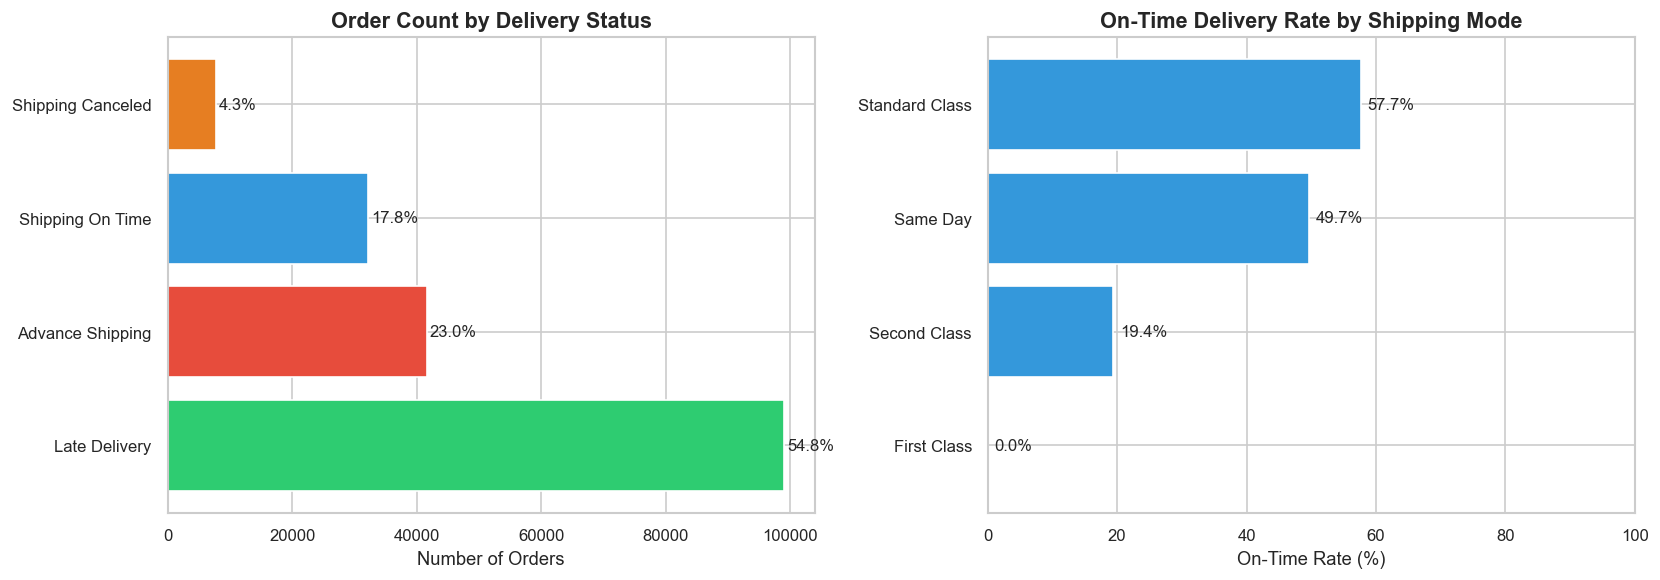


=== On-Time Rate by Shipping Mode ===
Shipping Mode
First Class        0.0
Second Class      19.4
Same Day          49.7
Standard Class    57.7


In [4]:
# Join delivery status labels back from dim_shipping
fact_ship = fact.merge(dim_ship, on='Shipping Id', how='left')

# Delivery status distribution
status_counts = fact_ship['Delivery Status'].value_counts()
status_pct = (status_counts / len(fact_ship) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Delivery status breakdown
colors = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22']
axes[0].barh(status_counts.index, status_counts.values, color=colors)
axes[0].set_title('Order Count by Delivery Status')
axes[0].set_xlabel('Number of Orders')
for i, (val, pct) in enumerate(zip(status_counts.values, status_pct.values)):
    axes[0].text(val + 500, i, f'{pct}%', va='center', fontsize=10)

# Chart 2 — On-time rate by shipping mode
mode_perf = (fact_ship.groupby('Shipping Mode')['on_time_delivery']
             .mean()
             .mul(100)
             .round(1)
             .sort_values(ascending=True))

axes[1].barh(mode_perf.index, mode_perf.values, color='#3498db')
axes[1].set_title('On-Time Delivery Rate by Shipping Mode')
axes[1].set_xlabel('On-Time Rate (%)')
axes[1].set_xlim(0, 100)
for i, val in enumerate(mode_perf.values):
    axes[1].text(val + 1, i, f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('Figures/2_1_delivery_performance_overview.png', bbox_inches='tight')
plt.show()

print("\n=== On-Time Rate by Shipping Mode ===")
print(mode_perf.to_string())

### 2.2 — Delivery Performance by Market and Region

The shipping mode breakdown tells us what is late — the regional breakdown tells us where. We examine on-time rates across the five global markets and then drill into the 23 order regions to identify the worst performing areas.

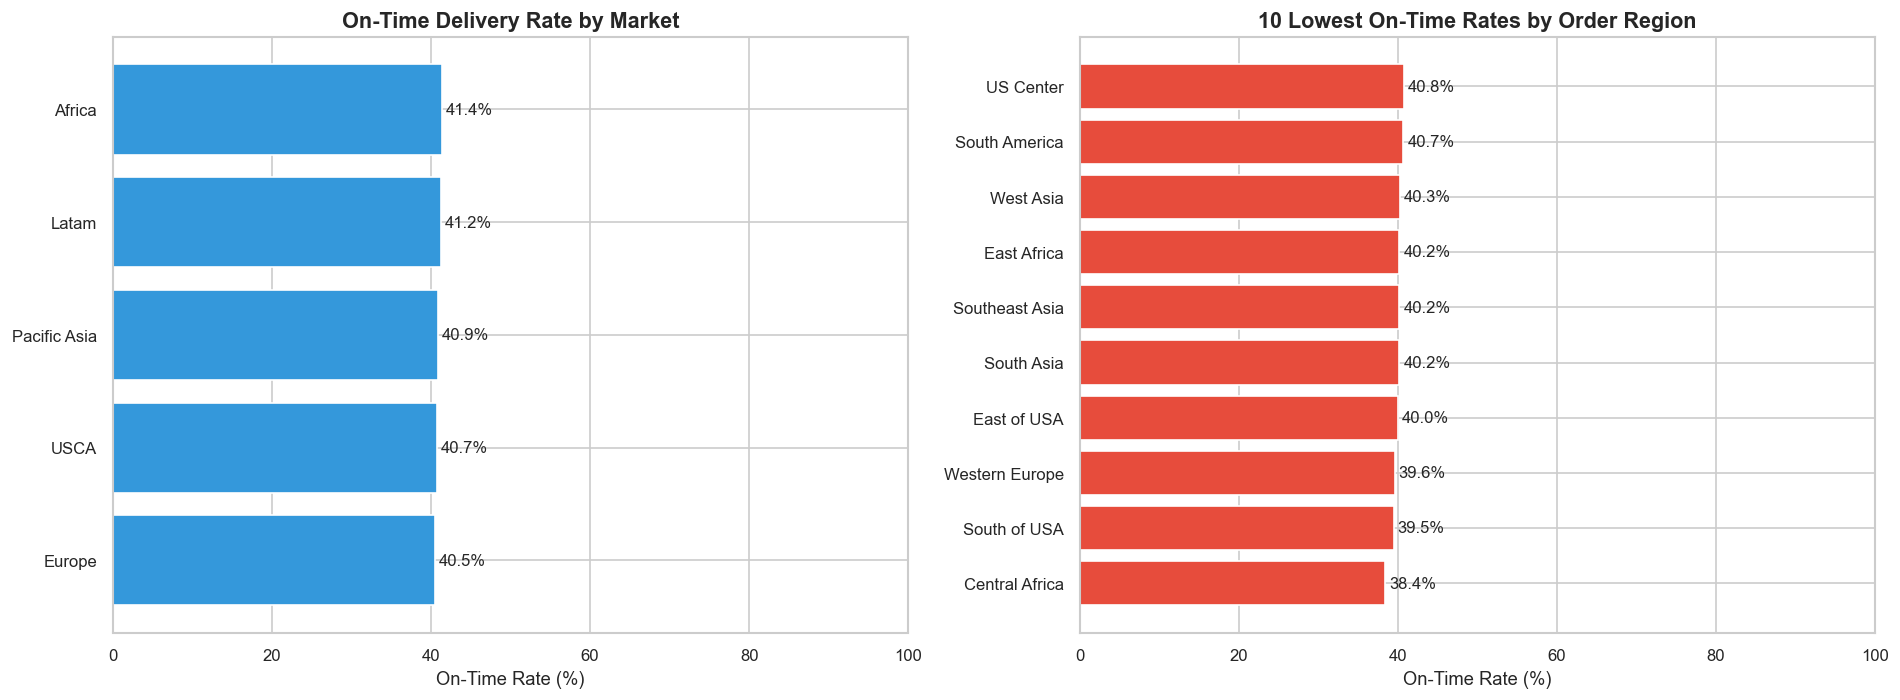


=== On-Time Rate by Market ===
Market
Europe          40.5
USCA            40.7
Pacific Asia    40.9
Latam           41.2
Africa          41.4


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — On-time rate by market
market_perf = (fact.groupby('Market')['on_time_delivery']
               .mean()
               .mul(100)
               .round(1)
               .sort_values(ascending=True))

axes[0].barh(market_perf.index, market_perf.values, color='#3498db')
axes[0].set_title('On-Time Delivery Rate by Market')
axes[0].set_xlabel('On-Time Rate (%)')
axes[0].set_xlim(0, 100)
for i, val in enumerate(market_perf.values):
    axes[0].text(val + 0.5, i, f'{val}%', va='center', fontsize=10)

# Chart 2 — On-time rate by region (bottom 10 worst performing)
region_perf = (fact.groupby('Order Region')['on_time_delivery']
               .mean()
               .mul(100)
               .round(1)
               .sort_values(ascending=True)
               .head(10))

axes[1].barh(region_perf.index, region_perf.values, color='#e74c3c')
axes[1].set_title('10 Lowest On-Time Rates by Order Region')
axes[1].set_xlabel('On-Time Rate (%)')
axes[1].set_xlim(0, 100)
for i, val in enumerate(region_perf.values):
    axes[1].text(val + 0.5, i, f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('Figures/2_2_performance_by_market_region.png', bbox_inches='tight')
plt.show()

print("\n=== On-Time Rate by Market ===")
print(market_perf.to_string())

### 2.3 — Delivery Performance Trend Over Time

Having established where performance is weakest, we now examine whether it is improving or deteriorating. On-time rates are plotted quarterly across 2015–2017 to identify any directional trend.

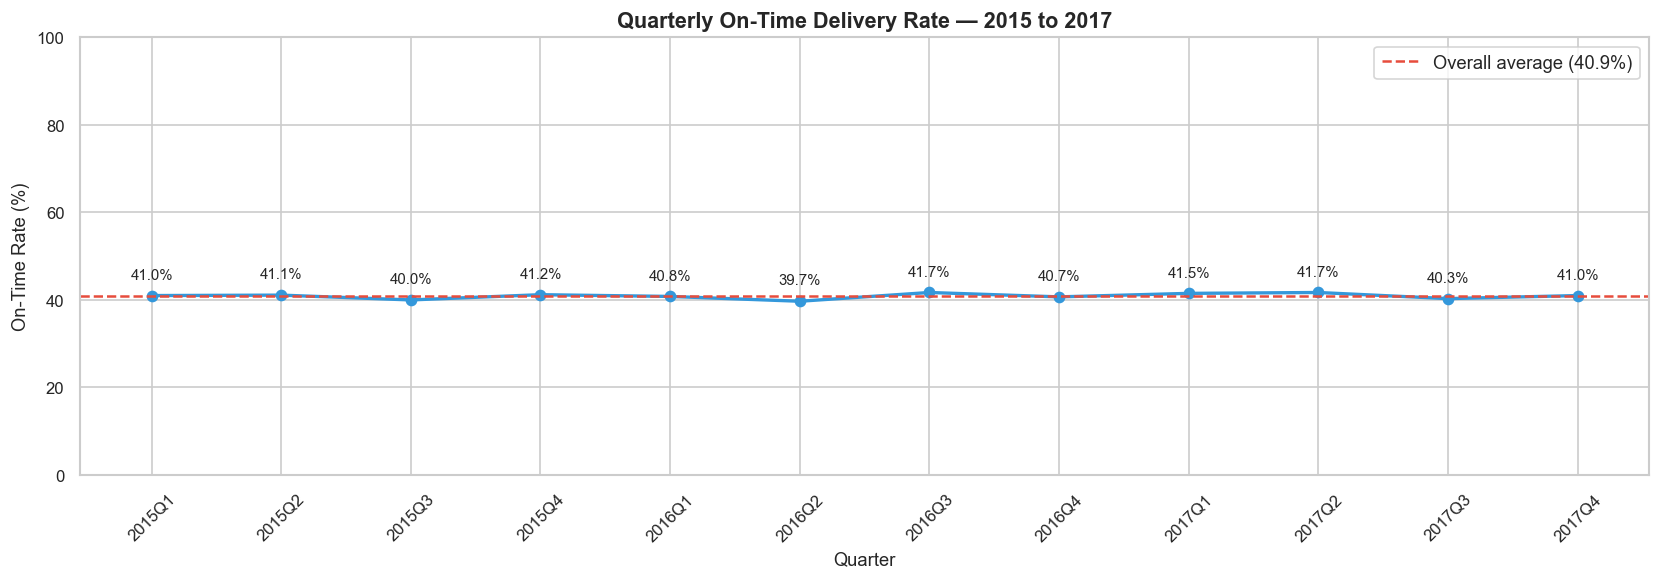

In [6]:
# Exclude 2018 — incomplete year
fact_trend = fact[fact['order_year'] != 2018].copy()

# Quarterly on-time rate
quarterly = (fact_trend.groupby('order_quarter')['on_time_delivery']
             .mean()
             .mul(100)
             .round(1)
             .reset_index())

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(quarterly['order_quarter'],
        quarterly['on_time_delivery'],
        marker='o', linewidth=2, color='#3498db', markersize=6)

ax.axhline(y=40.9, color='#e74c3c', linestyle='--',
           linewidth=1.5, label='Overall average (40.9%)')

ax.set_title('Quarterly On-Time Delivery Rate — 2015 to 2017')
ax.set_xlabel('Quarter')
ax.set_ylabel('On-Time Rate (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=45)
ax.legend()

# Annotate each point
for _, row in quarterly.iterrows():
    ax.annotate(f"{row['on_time_delivery']}%",
                xy=(row['order_quarter'], row['on_time_delivery']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('Figures/2_3_quarterly_ontime_trend.png', bbox_inches='tight')
plt.show()

### 2.4 — Late Delivery Heatmap — Market vs Shipping Mode

The final logistics view combines market and shipping mode into a single heatmap to identify which specific combinations drive the highest late delivery rates. This directly feeds into the risk matrix on the Power BI logistics page.

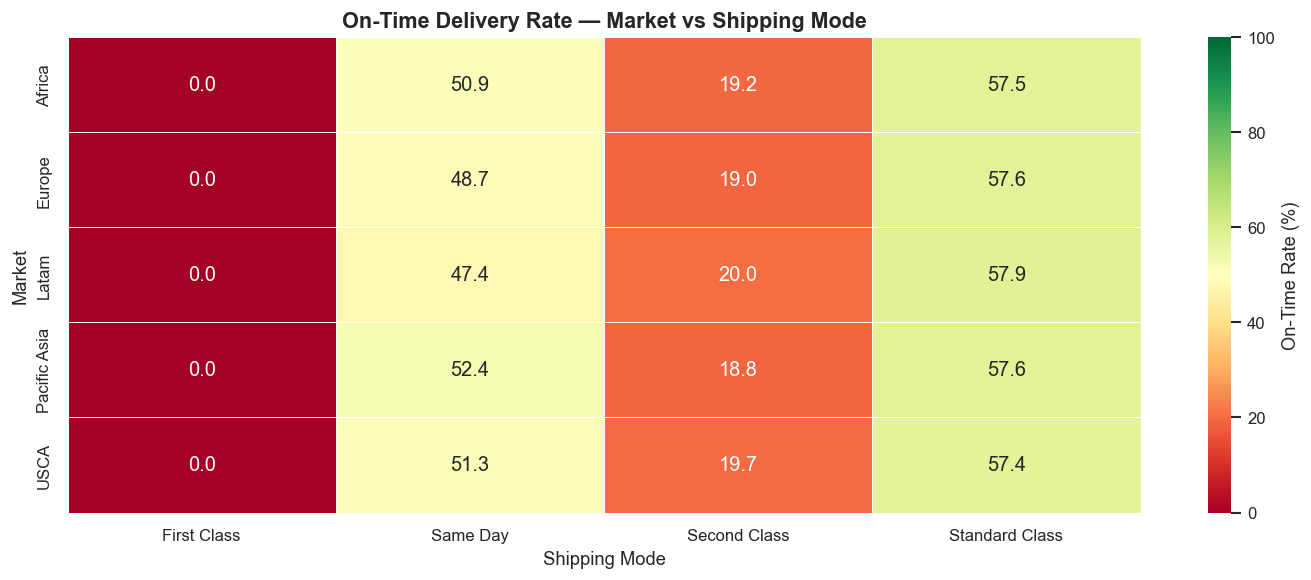

In [7]:
# Late delivery rate: market × shipping mode
heatmap_data = (fact_ship.groupby(['Market', 'Shipping Mode'])['on_time_delivery']
                .mean()
                .mul(100)
                .round(1)
                .unstack())

fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(heatmap_data,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            linewidths=0.5,
            ax=ax,
            vmin=0,
            vmax=100,
            cbar_kws={'label': 'On-Time Rate (%)'})

ax.set_title('On-Time Delivery Rate — Market vs Shipping Mode')
ax.set_xlabel('Shipping Mode')
ax.set_ylabel('Market')

plt.tight_layout()
plt.savefig('Figures/2_4_heatmap_market_shippingmode.png', bbox_inches='tight')
plt.show()

### Section 2 Findings

**Overall delivery performance** confirms the headline number: 54.8% of all orders are late deliveries — the single largest category. Advance shipping accounts for 23.0% and shipping on time for 17.8%, meaning only 40.9% of orders are delivered on schedule or early. Cancelled shipments represent 4.3%.

**Shipping mode** reveals the most striking finding in the logistics analysis. First Class has a 0.0% on-time rate — every single First Class order in the dataset is late. Standard Class performs best at 57.7%, followed by Same Day at 49.7% and Second Class at 19.4%. The heatmap confirms this pattern holds uniformly across all five markets — First Class failure is not a regional problem, it is a systemic one across the entire operation.

**Market and region** differences are negligible. All five markets cluster between 40.5% and 41.4% — a range of less than one percentage point. The ten worst-performing regions similarly cluster tightly between 38.4% and 40.8%. Central Africa is the single weakest region at 38.4% but even this is only 2.5 points below the overall average. The delivery performance problem is not geographically concentrated — it is uniform across all markets and regions.

**Quarterly trend** is the most operationally significant finding of this section: performance has not improved at all across three years. Every quarter from 2015Q1 through 2017Q4 sits within a 2-point band around the 40.9% average. There is no upward trajectory. The business has operated at roughly 40% on-time delivery for three consecutive years with no meaningful change.

The combination of these findings points to a structural operational problem rather than a logistical one — the issue is not where orders are going or how the network is distributed, but how specific shipping modes are being processed and fulfilled.

## Section 3 — Commercial Analysis

This section examines the revenue and profit patterns across departments, categories, products, and customer segments. The final subsection integrates the access log browsing data to compare what customers browse against what they actually purchase — a browse-to-purchase analysis that reveals where commercial conversion is strongest and weakest.

### 3.1 — Revenue and Profit by Department

The dataset covers six departments. We examine both revenue contribution and profit margin by department — these do not always align, and the gap between the two is where the most actionable commercial insight sits.

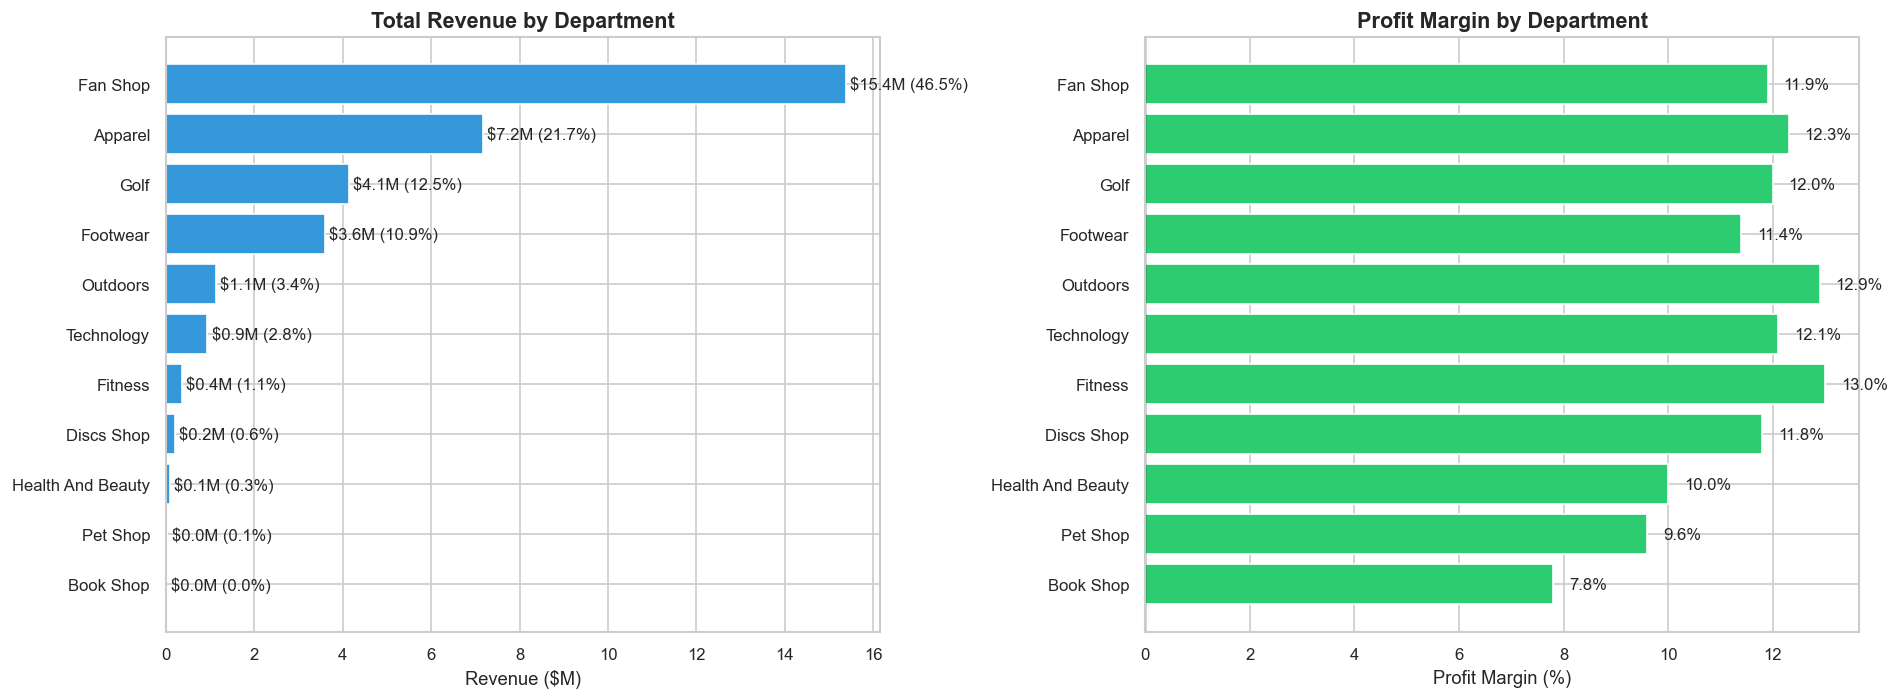

=== Department Summary ===
  Department Name  Revenue ($M)  Margin (%)  Revenue Share (%)
         Fan Shop         15.38        11.9               46.5
          Apparel          7.17        12.3               21.7
             Golf          4.14        12.0               12.5
         Footwear          3.60        11.4               10.9
         Outdoors          1.13        12.9                3.4
       Technology          0.93        12.1                2.8
          Fitness          0.36        13.0                1.1
       Discs Shop          0.21        11.8                0.6
Health And Beauty          0.10        10.0                0.3
         Pet Shop          0.04         9.6                0.1
        Book Shop          0.01         7.8                0.0


In [8]:
# Join product dimension to get department names
fact_prod = fact.merge(dim_prod[['Product Card Id', 'Department Name', 
                                  'Category Name', 'Product Name']], 
                        on='Product Card Id', how='left')

# Revenue and profit by department
dept = (fact_prod.groupby('Department Name')
        .agg(
            total_revenue=('Sales per customer', 'sum'),
            total_profit=('Benefit per order', 'sum'),
            order_count=('Order Id', 'count')
        )
        .reset_index())

dept['profit_margin'] = (dept['total_profit'] / dept['total_revenue'] * 100).round(1)
dept['revenue_pct'] = (dept['total_revenue'] / dept['total_revenue'].sum() * 100).round(1)
dept = dept.sort_values('total_revenue', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Revenue by department
bars = axes[0].barh(dept['Department Name'], dept['total_revenue'] / 1e6, 
                     color='#3498db')
axes[0].set_title('Total Revenue by Department')
axes[0].set_xlabel('Revenue ($M)')
for i, (val, pct) in enumerate(zip(dept['total_revenue'], dept['revenue_pct'])):
    axes[0].text(val/1e6 + 0.1, i, f'${val/1e6:.1f}M ({pct}%)', 
                 va='center', fontsize=10)

# Chart 2 — Profit margin by department
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in dept['profit_margin']]
axes[1].barh(dept['Department Name'], dept['profit_margin'], color=colors)
axes[1].set_title('Profit Margin by Department')
axes[1].set_xlabel('Profit Margin (%)')
axes[1].axvline(x=0, color='black', linewidth=0.8)
for i, val in enumerate(dept['profit_margin']):
    axes[1].text(val + 0.3, i, f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('Figures/3_1_revenue_profit_by_department.png', bbox_inches='tight')
plt.show()

dept_display = dept[['Department Name', 'total_revenue', 
                      'profit_margin', 'revenue_pct']].copy()
dept_display.columns = ['Department Name', 'Revenue ($M)', 
                         'Margin (%)', 'Revenue Share (%)']
dept_display['Revenue ($M)'] = (dept_display['Revenue ($M)'] / 1e6).round(2)
dept_display = dept_display.sort_values('Revenue ($M)', ascending=False)

print("=== Department Summary ===")
print(dept_display.to_string(index=False))

### 3.2 — Category-Level Analysis

Within departments, revenue and margin vary significantly by product category. We identify the top revenue-generating categories and examine which categories are most and least profitable

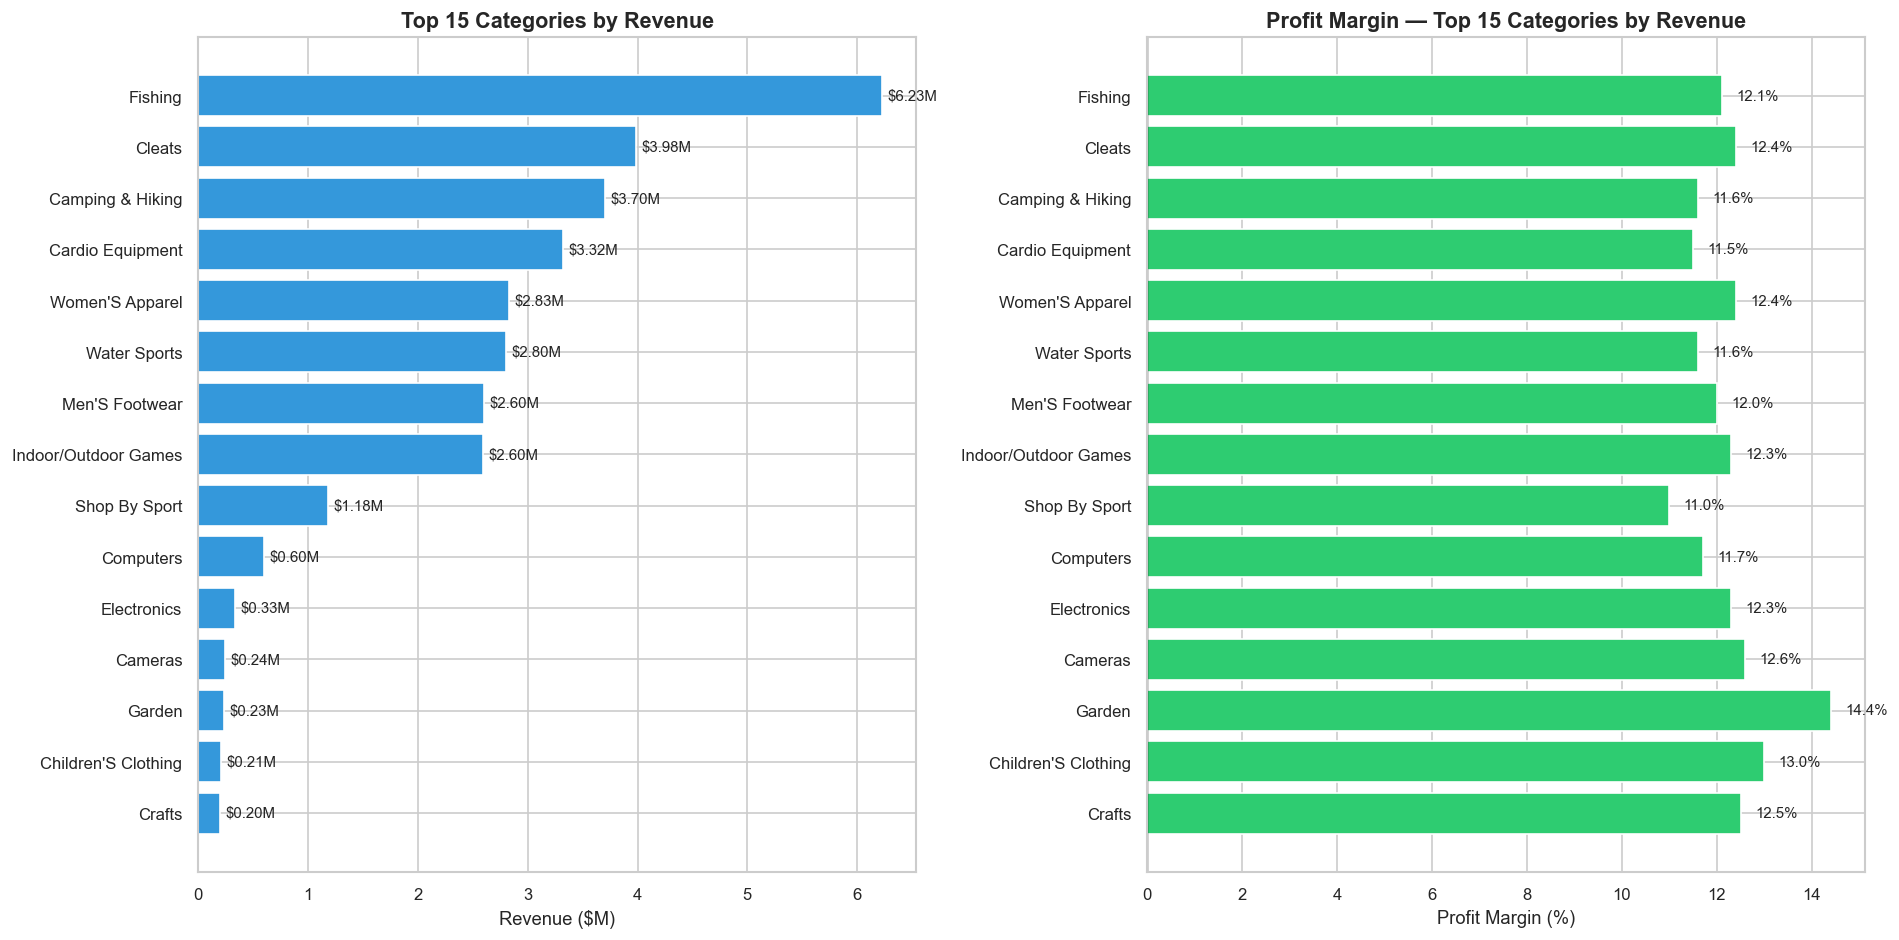

In [9]:
# Revenue and margin by category — top 15
cat = (fact_prod.groupby('Category Name')
       .agg(
           total_revenue=('Sales per customer', 'sum'),
           total_profit=('Benefit per order', 'sum'),
           order_count=('Order Id', 'count')
       )
       .reset_index())

cat['profit_margin'] = (cat['total_profit'] / cat['total_revenue'] * 100).round(1)
cat_top = cat.sort_values('total_revenue', ascending=False).head(15)
cat_top_sorted = cat_top.sort_values('total_revenue', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Chart 1 — Top 15 categories by revenue
axes[0].barh(cat_top_sorted['Category Name'], 
             cat_top_sorted['total_revenue'] / 1e6,
             color='#3498db')
axes[0].set_title('Top 15 Categories by Revenue')
axes[0].set_xlabel('Revenue ($M)')
for i, val in enumerate(cat_top_sorted['total_revenue']):
    axes[0].text(val/1e6 + 0.05, i, f'${val/1e6:.2f}M', 
                 va='center', fontsize=9)

# Chart 2 — Profit margin for same top 15 categories
colors = ['#e74c3c' if x < 0 else '#2ecc71' 
          for x in cat_top_sorted['profit_margin']]
axes[1].barh(cat_top_sorted['Category Name'], 
             cat_top_sorted['profit_margin'], color=colors)
axes[1].set_title('Profit Margin — Top 15 Categories by Revenue')
axes[1].set_xlabel('Profit Margin (%)')
axes[1].axvline(x=0, color='black', linewidth=0.8)
for i, val in enumerate(cat_top_sorted['profit_margin']):
    axes[1].text(val + 0.3, i, f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('Figures/3_2_category_revenue_margin.png', bbox_inches='tight')
plt.show()

### 3.3 — Customer Segment Analysis

The dataset contains three customer segments: Consumer, Corporate, and Home Office. We examine how revenue, order volume, and profit margin differ across segments, and whether delivery performance varies by segment.

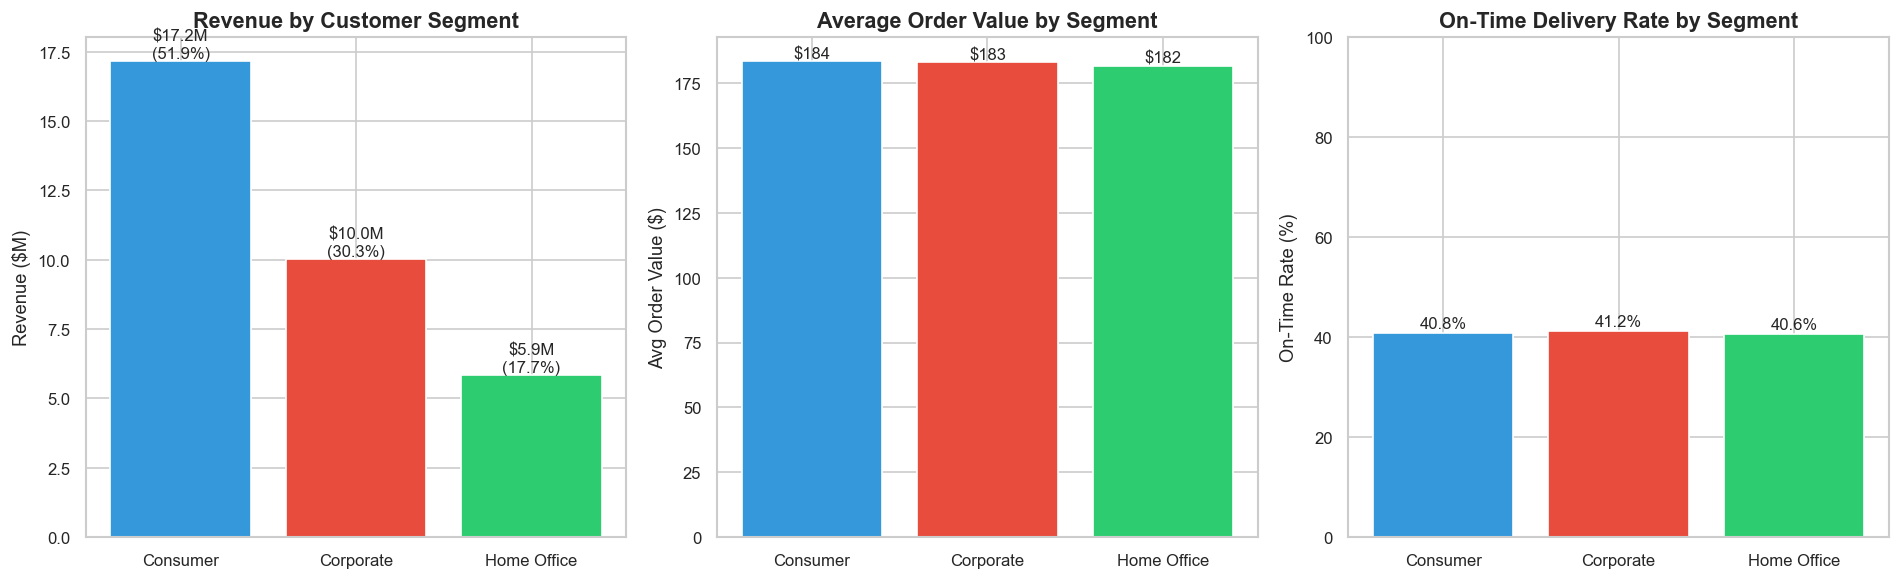

=== Customer Segment Summary ===
    Segment  Revenue ($M)  Revenue Share (%)  Avg Order ($)  Margin (%)  On-Time (%)
   Consumer         17.16               51.9          184.0        12.1         40.8
  Corporate         10.03               30.3          183.0        12.0         41.2
Home Office          5.86               17.7          182.0        11.8         40.6


In [10]:
# Join customer dimension
fact_cust = fact.merge(dim_cust[['Order Customer Id', 'Customer Segment']], 
                        on='Order Customer Id', how='left')

seg = (fact_cust.groupby('Customer Segment')
       .agg(
           total_revenue=('Sales per customer', 'sum'),
           total_profit=('Benefit per order', 'sum'),
           order_count=('Order Id', 'count'),
           avg_order_value=('Sales per customer', 'mean'),
           on_time_rate=('on_time_delivery', 'mean')
       )
       .reset_index())

seg['profit_margin'] = (seg['total_profit'] / seg['total_revenue'] * 100).round(1)
seg['revenue_pct'] = (seg['total_revenue'] / seg['total_revenue'].sum() * 100).round(1)
seg['on_time_rate'] = (seg['on_time_rate'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1 — Revenue share by segment
axes[0].bar(seg['Customer Segment'], seg['total_revenue'] / 1e6, 
            color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Revenue by Customer Segment')
axes[0].set_ylabel('Revenue ($M)')
for i, (val, pct) in enumerate(zip(seg['total_revenue'], seg['revenue_pct'])):
    axes[0].text(i, val/1e6 + 0.1, f'${val/1e6:.1f}M\n({pct}%)', 
                 ha='center', fontsize=10)

# Chart 2 — Average order value by segment
axes[1].bar(seg['Customer Segment'], seg['avg_order_value'], 
            color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title('Average Order Value by Segment')
axes[1].set_ylabel('Avg Order Value ($)')
for i, val in enumerate(seg['avg_order_value']):
    axes[1].text(i, val + 1, f'${val:.0f}', ha='center', fontsize=10)

# Chart 3 — On-time rate by segment
axes[2].bar(seg['Customer Segment'], seg['on_time_rate'], 
            color=['#3498db', '#e74c3c', '#2ecc71'])
axes[2].set_title('On-Time Delivery Rate by Segment')
axes[2].set_ylabel('On-Time Rate (%)')
axes[2].set_ylim(0, 100)
for i, val in enumerate(seg['on_time_rate']):
    axes[2].text(i, val + 1, f'{val}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('Figures/3_3_customer_segment_analysis.png', bbox_inches='tight')
plt.show()

seg_display = seg.copy()
seg_display['Revenue ($M)'] = (seg_display['total_revenue'] / 1e6).round(2)
seg_display['Avg Order ($)'] = seg_display['avg_order_value'].round(0)
seg_display = seg_display[['Customer Segment', 'Revenue ($M)', 
                             'revenue_pct', 'Avg Order ($)', 
                             'profit_margin', 'on_time_rate']]
seg_display.columns = ['Segment', 'Revenue ($M)', 'Revenue Share (%)', 
                        'Avg Order ($)', 'Margin (%)', 'On-Time (%)']

print("=== Customer Segment Summary ===")
print(seg_display.to_string(index=False))

### 3.4 — Browse vs Purchase Analysis

The access log file contains 469,977 product browsing events from the same period as the order data. By comparing browse volume against actual purchase revenue by department, we can identify where commercial conversion is strongest — departments that generate high browse traffic but low revenue signal a conversion problem worth investigating

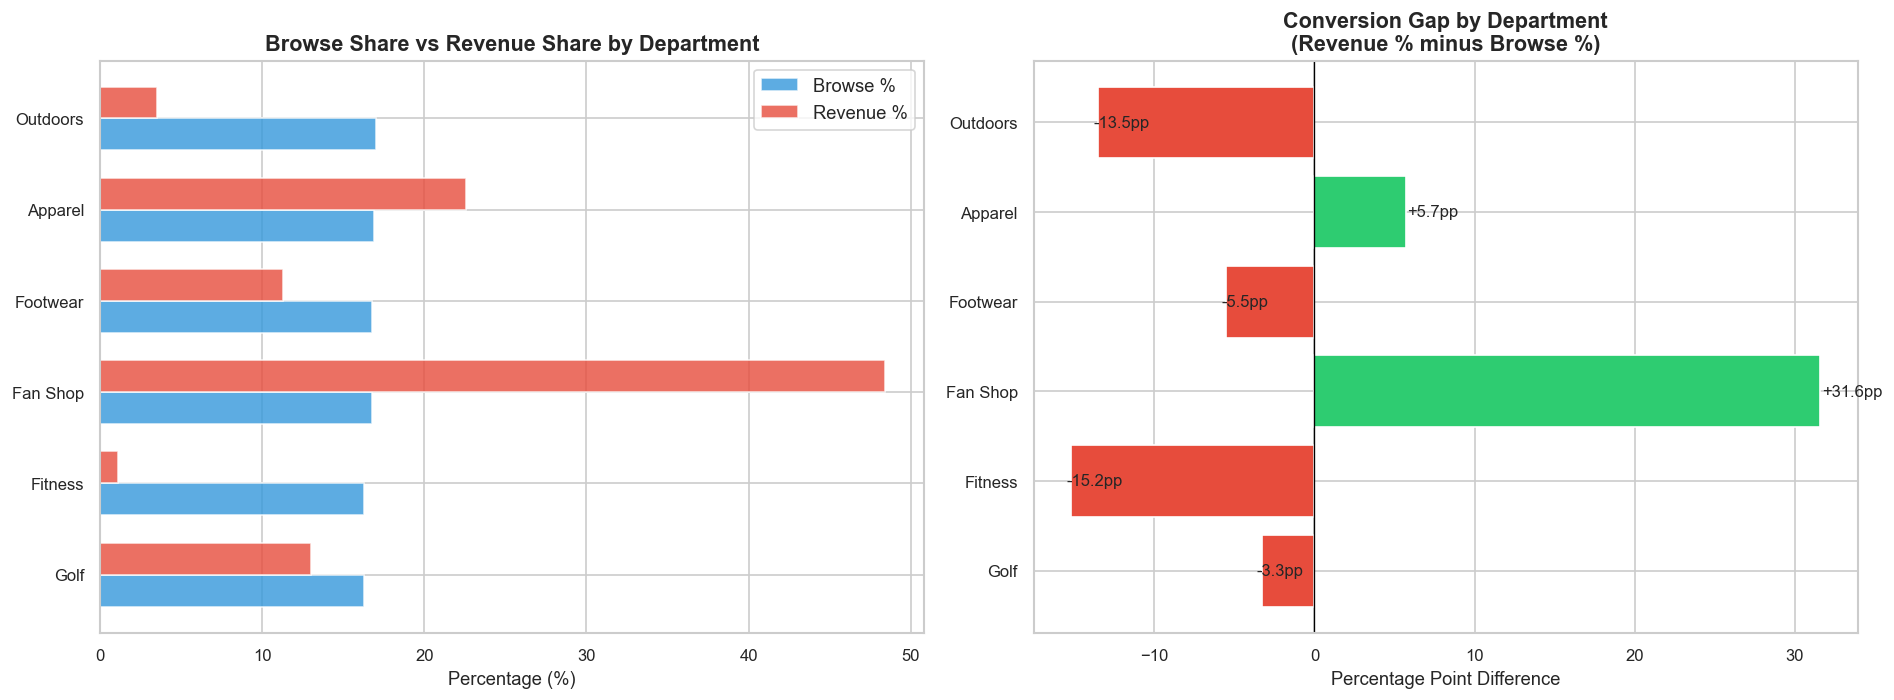

=== Browse vs Purchase Summary ===
url_department  browse_pct  revenue_pct  conversion_gap
      Fan Shop        16.8         48.4            31.6
       Apparel        16.9         22.6             5.7
          Golf        16.3         13.0            -3.3
      Footwear        16.8         11.3            -5.5
      Outdoors        17.0          3.5           -13.5
       Fitness        16.3          1.1           -15.2


In [11]:
# Parse URL components from access logs
logs['url_department'] = logs['url'].str.extract(r'/department/([^/]+)/', 
                                                   expand=False)
logs['url_department'] = (logs['url_department']
                          .str.replace('%20', ' ', regex=False)
                          .str.strip()
                          .str.title())

# Browse volume by department
browse = (logs.groupby('url_department')
          .size()
          .reset_index(name='browse_count'))

# Purchase revenue by department — use fact_prod which already has dept names
purchase = (fact_prod.groupby('Department Name')
            .agg(total_revenue=('Sales per customer', 'sum'))
            .reset_index()
            .rename(columns={'Department Name': 'url_department'}))

# Merge browse and purchase
browse_purchase = browse.merge(purchase, on='url_department', how='inner')
browse_purchase['browse_pct'] = (browse_purchase['browse_count'] / 
                                  browse_purchase['browse_count'].sum() * 100).round(1)
browse_purchase['revenue_pct'] = (browse_purchase['total_revenue'] / 
                                   browse_purchase['total_revenue'].sum() * 100).round(1)
browse_purchase['conversion_gap'] = (browse_purchase['revenue_pct'] - 
                                      browse_purchase['browse_pct']).round(1)
browse_purchase = browse_purchase.sort_values('browse_count', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Browse vs purchase share side by side
x = range(len(browse_purchase))
width = 0.35
axes[0].barh([i - width/2 for i in x], browse_purchase['browse_pct'], 
             width, label='Browse %', color='#3498db', alpha=0.8)
axes[0].barh([i + width/2 for i in x], browse_purchase['revenue_pct'], 
             width, label='Revenue %', color='#e74c3c', alpha=0.8)
axes[0].set_yticks(list(x))
axes[0].set_yticklabels(browse_purchase['url_department'])
axes[0].set_title('Browse Share vs Revenue Share by Department')
axes[0].set_xlabel('Percentage (%)')
axes[0].legend()

# Chart 2 — Conversion gap
colors = ['#2ecc71' if x >= 0 else '#e74c3c' 
          for x in browse_purchase['conversion_gap']]
axes[1].barh(browse_purchase['url_department'], 
             browse_purchase['conversion_gap'], color=colors)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Conversion Gap by Department\n(Revenue % minus Browse %)')
axes[1].set_xlabel('Percentage Point Difference')
for i, val in enumerate(browse_purchase['conversion_gap']):
    axes[1].text(val + 0.1 if val >= 0 else val - 0.3, i, 
                 f'{val:+.1f}pp', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('Figures/3_4_browse_vs_purchase.png', bbox_inches='tight')
plt.show()

print("=== Browse vs Purchase Summary ===")
print(browse_purchase[['url_department', 'browse_pct', 
                        'revenue_pct', 'conversion_gap']]
      .sort_values('conversion_gap', ascending=False)
      .to_string(index=False))

### Section 3 Findings

**Department revenue** is heavily concentrated. Fan Shop alone generates $15.4M — 46.5% of total revenue. Apparel adds a further 21.7%, meaning two departments account for 68% of all revenue. The remaining nine departments share the final 32%, with Book Shop, Pet Shop, and Health and Beauty each contributing less than 0.5% of total revenue.

Profit margin tells a different story. All eleven departments are profitable, ranging from 7.8% (Book Shop) to 13.0% (Fitness). Critically, the margin spread across departments is narrow — only 5.2 percentage points separates the best from the worst. Revenue concentration is a strategic question, not a profitability problem.

**Category level** shows Fishing as the single largest category at $6.23M, followed by Cleats at $3.98M and Camping & Hiking at $3.70M. Garden has the highest profit margin of any category at 14.4% despite ranking outside the top 10 by revenue — a small, high-margin category that is underrepresented relative to its profitability.

**Customer segments** show minimal differentiation across all three metrics. Consumer, Corporate, and Home Office generate $184, $183, and $182 average order values respectively — a difference of two dollars across segments. Profit margins sit at 12.1%, 12.0%, and 11.8%. On-time delivery rates are 40.8%, 41.2%, and 40.6%. The business treats all three segments identically and the outcomes reflect that — there is no segment receiving preferential service or generating meaningfully higher returns.

**Browse versus purchase** reveals the sharpest commercial insight in this analysis. All six departments receive almost identical browse traffic — between 16.3% and 17.0% each, meaning customers browse departments roughly equally. But Fan Shop converts that traffic into 48.4% of revenue — a conversion gap of +31.6 percentage points. Fitness is the mirror image: 16.3% browse share converting to only 1.1% of revenue, a gap of -15.2 points. Outdoors follows at -13.5 points.

The implication is clear: customers browse Fitness and Outdoors at the same rate as Fan Shop but do not purchase. Whether this is a pricing problem, a product assortment problem, or a site experience problem cannot be determined from this dataset alone — but the gap is large enough to warrant dedicated investigation.

## Analysis Complete

The exploratory analysis has identified two themes that anchor the Power BI dashboard:

**Logistics:** A structural delivery failure concentrated entirely in First Class shipping, operating at 0% on-time rate uniformly across all markets and regions, with no improvement across three years.

**Commercial:** Revenue heavily concentrated in Fan Shop despite equal browse traffic across all departments — Fitness and Outdoors attract customers but fail to convert them.

These findings are visualised in the Power BI dashboard — `supply_chain_dashboard.pbix` — across two pages: Logistics Performance and Sales & Commercial Analysis.